# Kvantumszámítógépek programozása 2.: algoritmus implementációja áramköri rajz segítségével

## Kvantuminformatikai alkalmazások,
### 2026 ősz

#### Dr. Solymos Balázs, Dr. Bacsárdi László, Dr. Imre Sándor
solymosb@hit.bme.hu

## Általános információk

Az órán a [Qiskit](https://qiskit.org/) python-os könyvtárat és a [Jupyter Notebook](https://jupyter.org/) környezetet használjuk.
Ha valaki saját gépen szeretné elvégezni a mérést, akkor fel kell telepíteni a Python-t, a Jupyter-t és a Qiskit-et. Az utolsó kettőt `pip` segítségével a következő módon lehet telepíteni egy már működő python installációhoz: 

```
pip install notebook
pip install qiskit[visualization]
pip install qiskit-ibm-runtime
pip install qiskit-aer
```

Ezután indítható el a Jupyter a "`jupyter notebook`" paranccsal.

## 1. Egyszerű kvantumos áramkörök a Qiskit-tel

Egy áramkört a "QuantumCircuit" osztály példányosításával tudunk létrehozni.

In [33]:
from qiskit import QuantumCircuit #importáljuk a megfelelő qiskit könyvtárat
qc = QuantumCircuit(3)            #létrehozunk egy QuantumCircuit példányt

A konstruktor paraméterének megadható, hogy mennyi qubit legyen az áramkörben. Az egy qubit-ekhez indexek tartoznak, melyek számozása 0-tól indul.

## Kapuk hozzáadása

Ha szeretnénk hozzáadni egy kaput az áramkörhöz, akkor azt az áramkör objektum megfelelő függvényével tudjuk megtenni.

In [34]:
qc.h(0)

Lehetőségünk van irányított kapukat is elhelyezni. Ekkor az első paraméter a kontrollbit indexe, míg a második a célbithez tartozó.

In [35]:
qc.cx(0,1)
qc.cx(0,2)

## Áramkör megjelenítése

Az áramkör megjeleníthető a "draw()" függvénnyel.

A függvény paraméter egy string, amivel megadható a kimenet formátuma. 

Pl.: "text", "latex" és "mpl".

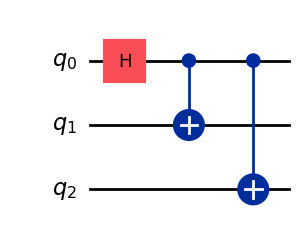

In [38]:

qc.draw("mpl")

## Áramkörök a qiskitben

Hogyan kezeli a qiskit az áramköröket?

Vizsgáljuk meg az egyszerű X kaput!

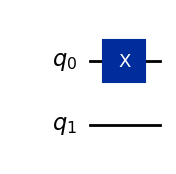

In [39]:
qc_x = QuantumCircuit(2,0)
qc_x.x(0)
qc_x.draw("mpl")

### Tárolt adatstruktúra

In [40]:
qc_x.data

[CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=())]

Az "X" kapu:

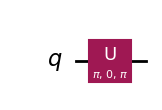

In [7]:
qc_x.data[0].operation.definition.draw('mpl')

Fontos, hogy a `CircuitInstruction` és `QuantumCircuit` különbözik, pedig mindkettő egy kvantumbit vagy kvantumbitek módosítását írja le.

### Áramkörök összekapcsolása
Két külön készített áramkör összekapcsolható a "compose" függvénnyel:

In [47]:
qc_a = QuantumCircuit(3) #Első áramkör
qc_a.x(1) 
qc_b = QuantumCircuit(2, name="qc_b") #Második áramkör
qc_b.x(0)
qc_b.z(1)
combined = qc_a.compose(qc_b, qubits=[1, 2]) #Összekapcsolás 

 A függvény első paramétere az áramkör, amit hozzá szeretnénk adni a megfelelő áramkörünkhöz. A második paraméter pedig azok a kvantumbitek, amiken hatni fog.

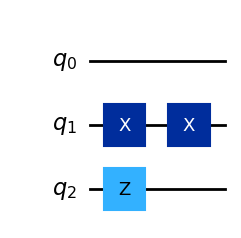

In [48]:
combined.draw("mpl")

### Áramkörök összekapcsolása 2.

Egy másik megoldás, ha az áramkörünket a ".to_instruction()" függvénnyel instrukcióvá alakítjuk. Ezután már elég csak úgy kezelni, mint pl. egy kaput.


In [49]:
qc_a = QuantumCircuit(3)
qc_a.x(1)
qc_b = QuantumCircuit(2, name="qc_b")
qc_b.x(0)
qc_b.z(1)
inst = qc_b.to_instruction()

Ezután az append függvénnyel tudunk a meglévő áramkörhöz új elemeket hozzáfűzni.
Itt szintén meg kell adni, hogy mely kvantumbitekre hasson az új elem.

In [50]:
qc_a.append(inst, [1, 2])

### Áramkörök összekapcsolása 2.

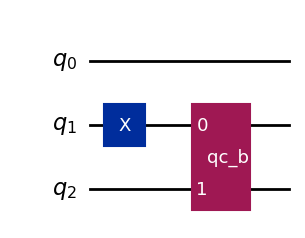

In [51]:
qc_a.draw("mpl")

A "decompose" függvény segítségével láthatjuk minden instrukció megvalósítását.

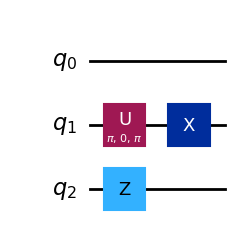

In [52]:
qc_a.decompose().draw("mpl")

### Vezérelt kapu készítése
Ha az áramkör, amit instrukcióként akarunk használni unitér, akkor úgy tudjuk kezelni, mint bármelyik más kaput. Például vezérelt változatot is tudunk készíteni belőle.

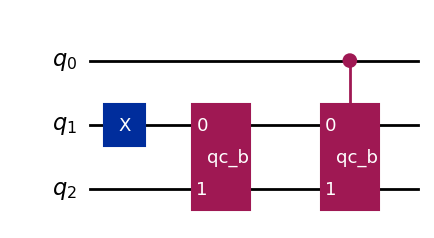

In [53]:
gate = qc_b.to_gate().control()
# Mivel ez egy vezérelt kapu, ezért 3 indexet kell megadni.
qc_a.append(gate, [0, 1, 2])
qc_a.draw("mpl")

### Vezérelt kapu készítése
Az áramkör dekompozíciója:

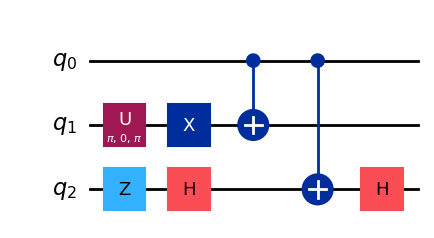

In [54]:
qc_a.decompose().draw("mpl")

## Áramkörök inicializálása állapotvektorral
Hálózat inicializáció (most regisztereket használva):

In [55]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
q = QuantumRegister(2,'q') #kvantumbiteket tartalmazó regiszter létrehozása
c = ClassicalRegister(2,'c') #klasszikus biteket tartalmazó regiszter
qc = QuantumCircuit(q,c) #kvantumhálózat készítése a regiszterekból

Állapotvektor megadása:

In [56]:
from qiskit.quantum_info import Statevector
state1 = Statevector([0.6,0.8])

Állapot inicializáció:

In [57]:
qc.initialize(state1,qubits=q[0], normalize=True)

Az elkészült hálózat:

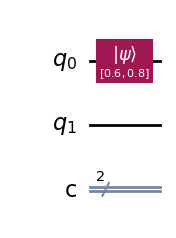

In [58]:
qc.draw("mpl")

Állapotvektor kinyerése a kvantumhálózatból:

In [59]:
state_qc = Statevector(qc)
print(state_qc)

Statevector([0.6+0.j, 0.8+0.j, 0. +0.j, 0. +0.j],
            dims=(2, 2))


Ismerős LaTeX formázásban is kiíratható az állapot:

In [60]:
from qiskit.visualization import array_to_latex
array_to_latex(state_qc) # Latex-es kiírás

<IPython.core.display.Latex object>

## Áramkörök futtatása

Az áramkörök futtatásához jellemzően valamilyen szimulátort használunk. (Lehetőség van természetesen a felhőben elérhető kvantumszámítógépek használatára is tokenek fejében, csak ott ki kell várni a várakozási sort.)

Legtöbbször úgy szeretnénk szimulálni az áramkört, hogy a végén klasszikus információt kapjunk.
Ehhez elengedhetetlen még hiányzó operáció a mérés, amely egy kvantumos regiszteren végrehajtja az előírt mérési operátort, és egy klasszikus regiszterbe írja a mérési eredményt.


Hozzunk létre egy kvantumos és klasszikus regisztereket is tartalmazó áramkört:

In [61]:
qc = QuantumCircuit(2,2) # a második paraméter a klasszikus bitek száma
qc.h(0)
qc.cx(0,1)
qc.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════

Használjuk az állapotvektor szimulátort!

In [62]:
from qiskit_aer import Aer
backend = Aer.get_backend("statevector_simulator")
job = backend.run(qc)
result = job.result() # Blokkoló hívás!
outputstate = result.get_statevector(qc)
array_to_latex(outputstate)

<IPython.core.display.Latex object>

 A measure függvény szolgál a mérések elhelyezésére, melynek első paramétere a mérni kívánt qubitek listája, a második a mérési eredményeket tároló klasszikus bitek listája. A méréshez használjuk az Aer szimulátort!

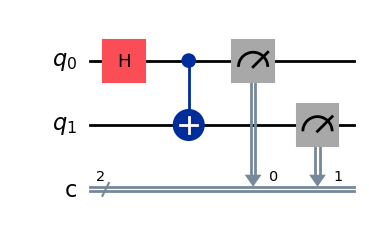

In [63]:
qc.measure(range(2), range(2))
qc.draw("mpl") 

In [65]:
backend = Aer.get_backend("aer_simulator")
result = backend.run(qc, shots=1000).result()
# A mérési eredményeket a result.get_counts függvénnyel tudjuk elérni.
counts = result.get_counts()
print(counts)

{'11': 500, '00': 500}


A mérési eredményeket hisztogrammal is szemléltethetjük.

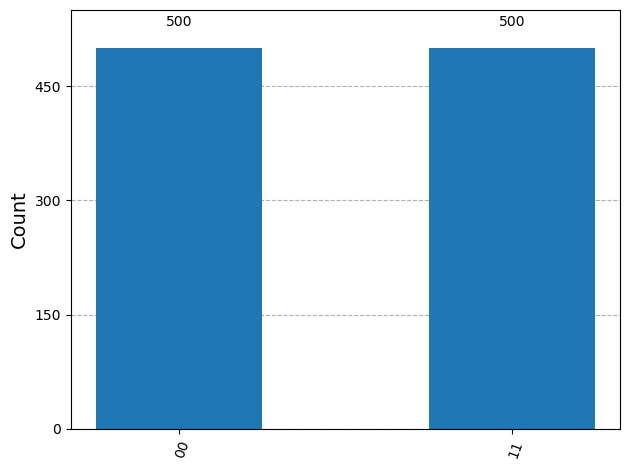

In [66]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

### Állapotvektorok kinyerése a szimulációból
Hálózat előkészítése:

In [67]:
q = QuantumRegister(2,'q') #kvantumbiteket tartalmazó regiszter létrehozása (q[index]-el indexelhetőek az egyes bitek)
c = ClassicalRegister(2,'c') #klasszikus biteket tartalmazó regiszter (c[index]-el indexelhetőek az egyes bitek)
qc = QuantumCircuit(q,c) #kvantumhálózat készítése a regiszterekból
qc.h(q[0]) #H kapu
qc.cx(q[0],q[1]) #CNOT kapu
qc.save_statevector(label = 'mereselott', pershot = True)
qc.measure(q[0],c[0])
qc.save_statevector(label = 'meresutan', pershot = True)
qc.measure(q[1],c[1])
qc.draw()

┌───┐      mereselott ┌─┐ meresutan    
q_0: ┤ H ├──■───────░──────┤M├─────░────────
     └───┘┌─┴─┐     ░      └╥┘     ░     ┌─┐
q_1: ─────┤ X ├─────░───────╫──────░─────┤M├
          └───┘     ░       ║      ░     └╥┘
c: 2/═══════════════════════╩═════════════╩═
                            0             1

Szimuláció:

In [68]:
from qiskit import transpile
backend = Aer.get_backend('qasm_simulator')
job_sim = backend.run(transpile(qc, backend), shots=4,memory=True) # 4-szer ismételjük meg a kísérletet, hogy statisztikát kapjunk és elvégezzük a mérést
#mérési eredmény kinyerése
result_sim = job_sim.result()
print(result_sim.data(0)['mereselott'])
print(result_sim.data(0)['meresutan'])

[Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2)), Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2)), Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2)), Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))]
[Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2)), Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))]


## Tetszőleges kvantumos állapot előkészítése
### $|0\rangle$ előjelváltása

Tetszőleges $\alpha|0\rangle + \beta|1\rangle$ állapotot szeretnénk a $-\alpha|0\rangle + \beta|1\rangle$ állapotba alakítani. Hogyan tudjuk ezt elérni Pauli-kapukkal?

In [69]:
from qiskit_aer import Aer

qc = QuantumCircuit(1) 
qc.initialize([0.6, 0.8], 0)
qc.x(0)
qc.z(0)
qc.x(0)
sim = Aer.get_backend("statevector_simulator")
output_state = sim.run(qc).result().get_statevector(qc)
print(output_state)

Statevector([-0.6+0.j,  0.8+0.j],
            dims=(2,))


## Tetszőleges kvantumos állapot előkészítése
### Globális fázis állítása

 $\alpha|0\rangle + \beta|1\rangle$ állapotból indulva jussunk el a: $e^{j\pi/4}\alpha|0\rangle + e^{j\pi/4}\beta|1\rangle$ állapotba!

In [73]:
from qiskit_aer import Aer
import numpy as np
qc = QuantumCircuit(1) 
qc.initialize([0.6, 0.8], 0)
angle = np.pi/4
qc.x(0)
qc.p(angle,0) # fázisforgató kapu - 1. paraméter: szög, 2. paraméter: qubit index
qc.x(0)
qc.p(angle,0)
sim = Aer.get_backend("statevector_simulator")
output_state = sim.run(qc).result().get_statevector(qc)
print(output_state)

Statevector([0.42426407+0.42426407j, 0.56568542+0.56568542j],
            dims=(2,))


## Tetszőleges kvantumos állapot előkészítése
Építsünk tetszőleges egybites kvantumos állapot létrehozására alkalmas kvantumáramkört!



In [31]:
import numpy as np
a = 0.6
b = 0.8 
param1 = 0
param2 = 0
param3 = 0
qc = QuantumCircuit(1)
# Készített hálózat itt....


print(Statevector(qc))
qc.draw()

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


q:

## Tetszőleges kvantumos állapot előkészítése
Építsünk tetszőleges egybites kvantumos állapot létrehozására alkalmas kvantumáramkört!

Cél: a|0> + b|1> állapot előkészítése egy kvantumregiszterben.

In [32]:
import numpy as np
a = -0.8
b = 0.6
alpha = 2* np.arccos(np.absolute(a))
beta= np.angle(b) - np.angle(a)
gamma = -0.5 * alpha + np.angle(a) 
qc = QuantumCircuit(1)
qc.h(0)
qc.p(alpha,0)
qc.h(0)
qc.p(beta + 0.5* np.pi,0)
qc.x(0)
qc.p(gamma,0)
qc.x(0)
qc.p(gamma,0)
print(Statevector(qc))
qc.draw()

Statevector([-0.8+4.13002965e-17j,  0.6-7.81597009e-17j],
            dims=(2,))


┌───┐┌──────────┐┌───┐┌─────────┐┌───┐┌───────────┐┌───┐┌───────────┐
q: ┤ H ├┤ P(1.287) ├┤ H ├┤ P(-π/2) ├┤ X ├┤ P(2.4981) ├┤ X ├┤ P(2.4981) ├
   └───┘└──────────┘└───┘└─────────┘└───┘└───────────┘└───┘└───────────┘